In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Calling libraries

In [3]:
!pip install imutils
from imutils import paths
from torchvision import transforms
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, ResNet101
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.losses import SparseCategoricalCrossentropy, BinaryCrossentropy
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import cv2
import os

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

# 👉 CHANGE THIS if your folder is inside another folder in Drive
base_path = "/content/drive/MyDrive/drawings"

# Check if path exists
print("Path exists:", os.path.exists(base_path))
print("Contents:", os.listdir(base_path))

Path exists: True
Contents: ['wave', 'spiral']


In [6]:
# Base path
parkinsons_dataset_path = base_path

print("Drawings folder contents:", os.listdir(parkinsons_dataset_path))

# Spiral path
spiral_dataset_path = os.path.join(parkinsons_dataset_path, "spiral")
print("Spiral folder contents:", os.listdir(spiral_dataset_path))

# Wave path
wave_dataset_path = os.path.join(parkinsons_dataset_path, "wave")
print("Wave folder contents:", os.listdir(wave_dataset_path))

# Spiral paths
spiralTrainingPath = os.path.join(spiral_dataset_path, "training")
spiralTestingPath = os.path.join(spiral_dataset_path, "testing")
spiralValidationPath = os.path.join(spiral_dataset_path, "validation")

# Wave paths
waveTrainingPath = os.path.join(wave_dataset_path, "training")
waveTestingPath = os.path.join(wave_dataset_path, "testing")
waveValidationPath = os.path.join(wave_dataset_path, "validation")

# Verification
print(f"Checking Spiral Training Path: {os.path.exists(spiralTrainingPath)}")
print(f"Checking Wave Training Path: {os.path.exists(waveTrainingPath)}")

Drawings folder contents: ['wave', 'spiral']
Spiral folder contents: ['training', 'testing', 'validation']
Wave folder contents: ['validation', 'testing', 'training']
Checking Spiral Training Path: True
Checking Wave Training Path: True


Paths

Preprocessing and augmentations

In [7]:
def load_split(path):
    imagePaths = list(paths.list_images(path))
    data = []
    labels = []

    #Define transformation for later
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
        transforms.Resize((224, 224)),  # Resize to 224x224 pixels
        transforms.ToTensor(),  # Convert the image to a PyTorch tensor
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize the image
    ])

    for imagePath in imagePaths:
        label = imagePath.split(os.path.sep)[-2]

        # Read and process image
        image = cv2.imread(imagePath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

        #Convert to numpy array and apply pre-defined transformation
        image_pil = Image.fromarray(image)

        image_tensor = transform(image_pil)
        image_np = image_tensor.permute(1, 2, 0).numpy()
        image_np = (image_np * 255).astype(np.uint8)

        data.append(image_np)
        labels.append(label)

    return np.array(data), np.array(labels)

In [8]:
def get_data_augmentation():
    return ImageDataGenerator(
        rotation_range=30,  # Rotation
        width_shift_range=0.2,  # Width shifts
        height_shift_range=0.2,  # Height shifts
        shear_range=0.2,  # Shear
        zoom_range=0.2,  # Zooms
        horizontal_flip=True,  # Horizontal flips
        fill_mode="nearest"  # Fill missing pixels after transformations
    )

Training

In [8]:
def cosine_annealing_schedule(epoch, lr_max=0.001, lr_min=0.00001, T_max=10):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / T_max))

import tensorflow as tf
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix
import numpy as np

def train_models(training_path, validating_path):
    models_dict = {
        "VGG19": {
            "classifier": VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
            "Accuracy": 0,
            "Precision": 0,
            "Recall": 0,
            "Mcc": 0,
            "Confusion Matrix": None
        },
        "ResNet101": {
            "classifier": ResNet101(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
            "Accuracy": 0,
            "Precision": 0,
            "Recall": 0,
            "Mcc": 0,
            "Confusion Matrix": None
        }
    }

    # Load training and validation data
    trainX, trainY = load_split(training_path)
    validX, validY = load_split(validating_path)

    # Encode labels
    le = LabelEncoder()
    trainY = le.fit_transform(trainY)
    validY = le.transform(validY)

    datagen = get_data_augmentation()

    for model_name, model_data in models_dict.items():
        model = model_data["classifier"]

        # Freeze base layers
        for layer in model.layers:
            layer.trainable = False

        # ----------- HEAD (UPDATED) -----------
        x = layers.Flatten()(model.output)
        x = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
        x = layers.Dropout(0.6)(x)

        # 🔥 CHANGE 1: REMOVE sigmoid → use logits
        predictions = layers.Dense(1, activation=None)(x)

        final_model = models.Model(inputs=model.input, outputs=predictions)

        # 🔥 CHANGE 2: use from_logits=True
        final_model.compile(
            optimizer=Adam(learning_rate=0.00005),
            loss=BinaryCrossentropy(from_logits=True),
            metrics=['accuracy']
        )

        # Callbacks
        lr_scheduler = LearningRateScheduler(
            lambda epoch: cosine_annealing_schedule(epoch, lr_max=0.001, lr_min=0.00001, T_max=10)
        )
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        # Dataset
        train_dataset = tf.data.Dataset.from_tensor_slices((trainX, trainY)).batch(16)
        validation_dataset = tf.data.Dataset.from_tensor_slices((validX, validY)).batch(16)

        # Train
        history = final_model.fit(
            train_dataset,
            epochs=50,
            validation_data=validation_dataset,
            callbacks=[lr_scheduler, early_stop]
        )

        # 🔥 CHANGE 3: Use logits → convert to probability manually
        logits = final_model.predict(trainX)
        probs = 1 / (1 + np.exp(-logits))  # sigmoid manually

        train_predictions = (probs > 0.5).astype("int32").flatten()

        # Confusion matrix
        cm = confusion_matrix(trainY, train_predictions)

        if cm.shape[0] == 1:
            cm = np.array([[cm[0, 0], 0], [0, cm[0, 0]]])

        tp = cm[1, 1]
        tn = cm[0, 0]
        fp = cm[0, 1]
        fn = cm[1, 0]

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0

        denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
        mcc = (tp * tn - fp * fn) / denominator if denominator != 0 else 0

        # Store results
        model_data["Accuracy"] = accuracy
        model_data["Precision"] = precision
        model_data["Recall"] = recall
        model_data["Mcc"] = mcc
        model_data["Confusion Matrix"] = cm
        model_data["History"] = history
        model_data["Compiled_Model"] = final_model

    return models_dict, le

Building graphs

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(cm, class_names, model_name):
    """Function to plot confusion matrix as heatmap."""
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name="Model"):
    # Extract accuracy and loss values
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Plot accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


Code for testing model

In [9]:
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_on_test_data(model, test_path, le, class_names):
    """
    Evaluate the model on a completely independent test dataset.

    Args:
        model: The trained Keras model.
        test_path: Path to the test dataset.
        le: LabelEncoder used during training to encode class labels.
        class_names: List of class names.

    Returns:
        None (prints performance metrics).
    """
    # Load and preprocess the test data
    testX, testY = load_split(test_path)  # Use existing load_split function
    testY = le.fit_transform(testY)  # Encode labels using the same encoder used during training

    # Create a TensorFlow dataset
    test_dataset = tf.data.Dataset.from_tensor_slices((testX, testY)).batch(16)

    # Evaluate the model on the test dataset
    loss, accuracy = model.evaluate(test_dataset)

    # Make predictions
    logits = model.predict(test_dataset)
    probs = 1 / (1 + np.exp(-logits)) # Probabilities

    binary_predicted_labels = (probs > 0.5).astype("int32").flatten() # 0 or 1 labels
    string_predicted_labels = le.inverse_transform(binary_predicted_labels)  # Convert to original labels for classification report

    # Get true labels
    true_labels = le.inverse_transform(testY)

    #printing loss and accuracy
    print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, string_predicted_labels, target_names=class_names))

    #visualisation code

    code = {'Healthy':0,'Parkinson':1}

    def getcode(n) :
        for x , y in code.items() :
            if n == y :
                return x

    plt.figure(figsize=(20,20))
    # Select random indices to display
    random_indices = np.random.randint(0, len(testX), 14)

    for n , i in enumerate(random_indices):
        plt.subplot(6,6,n+1)
        plt.imshow(testX[i])
        plt.axis('off')
        predicted_label_code = binary_predicted_labels[i] # Use the 0/1 prediction for the title mapping
        plt.title(getcode(predicted_label_code))
    plt.show()


**Training and testing on spiral data**

In [ ]:
spiral_results,le = train_models(spiralTrainingPath, spiralValidationPath)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7238 - loss: 60.7910 - val_accuracy: 0.5128 - val_loss: 83.2268 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.3757 - loss: 72.5171 - val_accuracy: 0.8718 - val_loss: 4.3384 - learning_rate: 9.7577e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.7901 - loss: 3.2188 - val_accuracy: 0.8974 - val_loss: 2.0258 - learning_rate: 9.0546e-04
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.6740 - loss: 1.8963 - val_accuracy: 0.8718 - val_loss: 0.2679 - learning_rate: 7.9595e-04
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.7459 - loss: 0.3523 - val_accuracy: 0.8462 - val_loss: 0.3390 - learning_rate: 6.5796e-04
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.7072 - loss: 0.3595 - val_accuracy: 0.8462 - val_loss

In [ ]:
print("VGG19 vs ResNet101\n\n")
for metric in ("Accuracy", "Precision","Recall","Mcc"):
    print(f"{metric.capitalize()}: ")
    print("VGG19={:.2f}%, ResNet101={:.2f}% \n".format(
        spiral_results["VGG19"][metric]*100, spiral_results["ResNet101"][metric]*100))

VGG19 vs ResNet101


Accuracy: 
VGG19=93.92%, ResNet101=91.16% 

Precision: 
VGG19=95.24%, ResNet101=96.10% 

Recall: 
VGG19=91.95%, ResNet101=85.06% 

Mcc: 
VGG19=87.86%, ResNet101=82.73% 



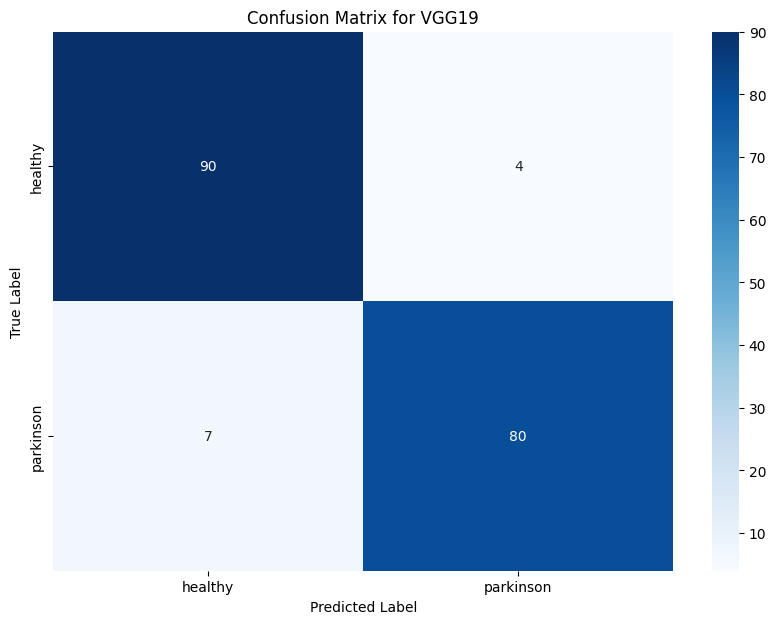

In [ ]:
model_data1 = spiral_results.get("VGG19")
if model_data1:
        cm = model_data1["Confusion Matrix"]
        class_names = le.classes_  # Assumes you have le available from training
        plot_confusion_matrix(cm, class_names, "VGG19")

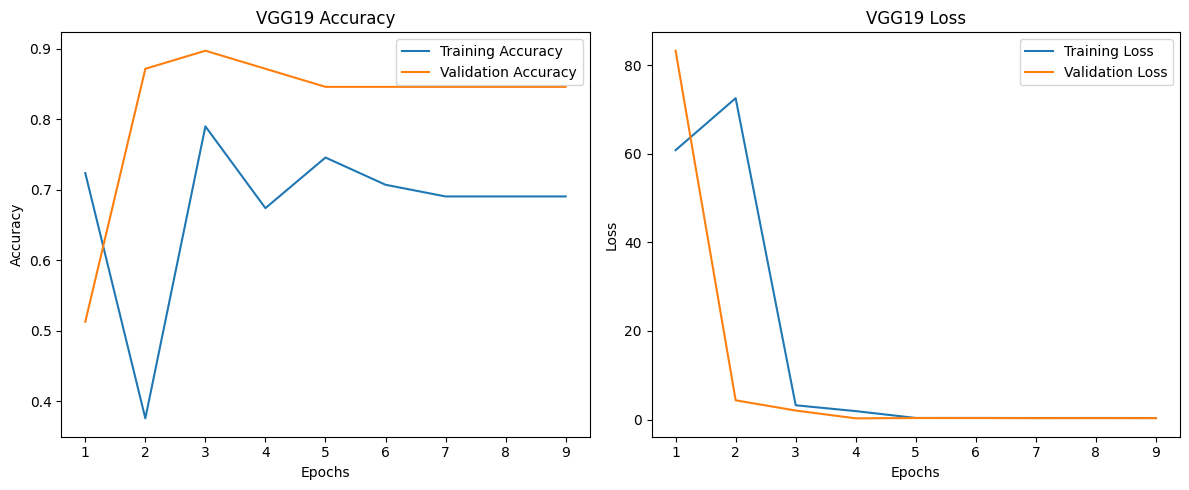

In [ ]:
plot_training_history(spiral_results["VGG19"]["History"], model_name="VGG19")

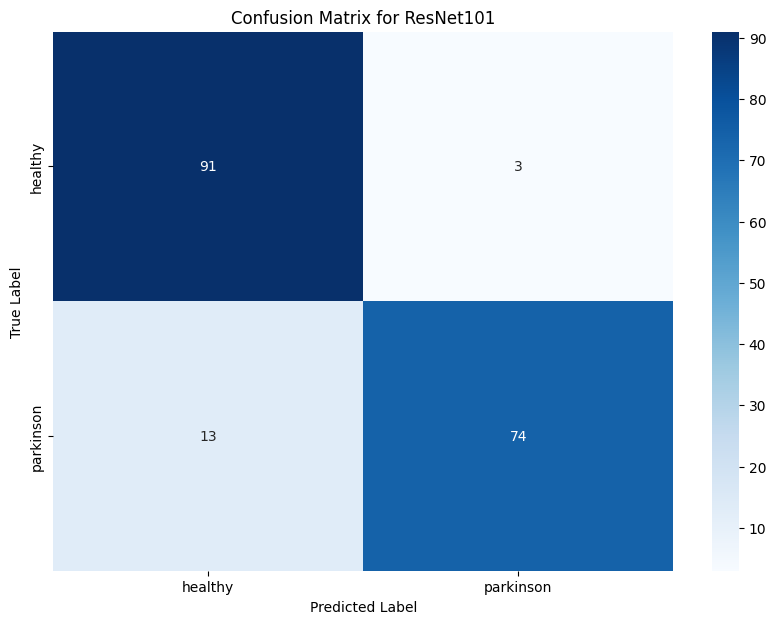

In [ ]:
model_data2 = spiral_results.get("ResNet101")
if model_data2:
        cm = model_data2["Confusion Matrix"]
        class_names = le.classes_  # Assumes you have le available from training
        plot_confusion_matrix(cm, class_names, "ResNet101")

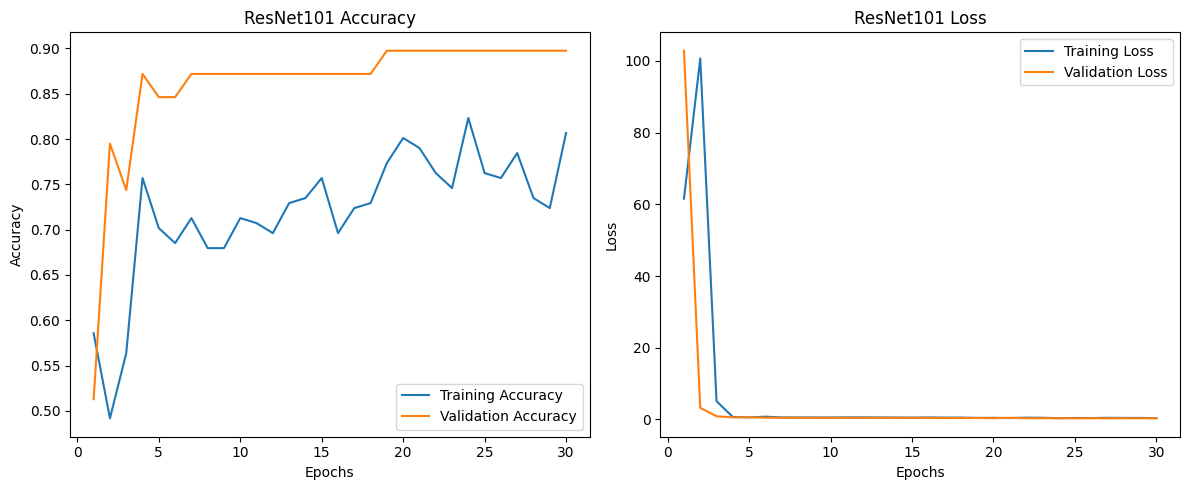

In [ ]:
plot_training_history(spiral_results["ResNet101"]["History"], model_name="ResNet101")

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.9474 - loss: 0.2179


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 573ms/step
Test Loss: 0.2179, Test Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.95      0.95      0.95        19
  Parkinsons       0.95      0.95      0.95        19

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



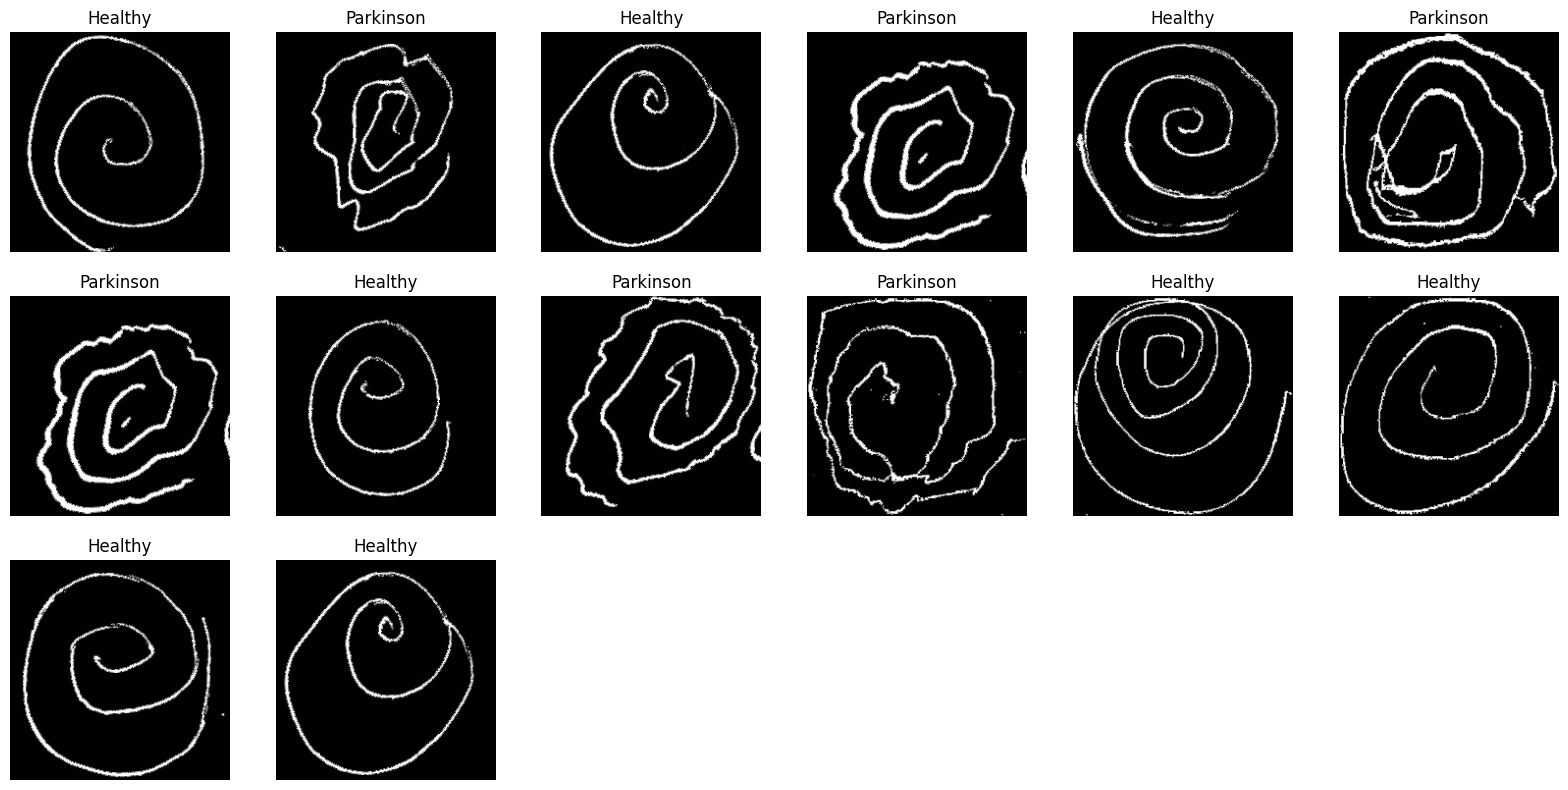

In [ ]:
class_names = ["Healthy", "Parkinsons"]
evaluate_on_test_data(spiral_results["VGG19"]["Compiled_Model"], spiralTestingPath, le, class_names)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9737 - loss: 0.1696
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step
Test Loss: 0.1696, Test Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.95      1.00      0.97        19
  Parkinsons       1.00      0.95      0.97        19

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.97      0.97      0.97        38



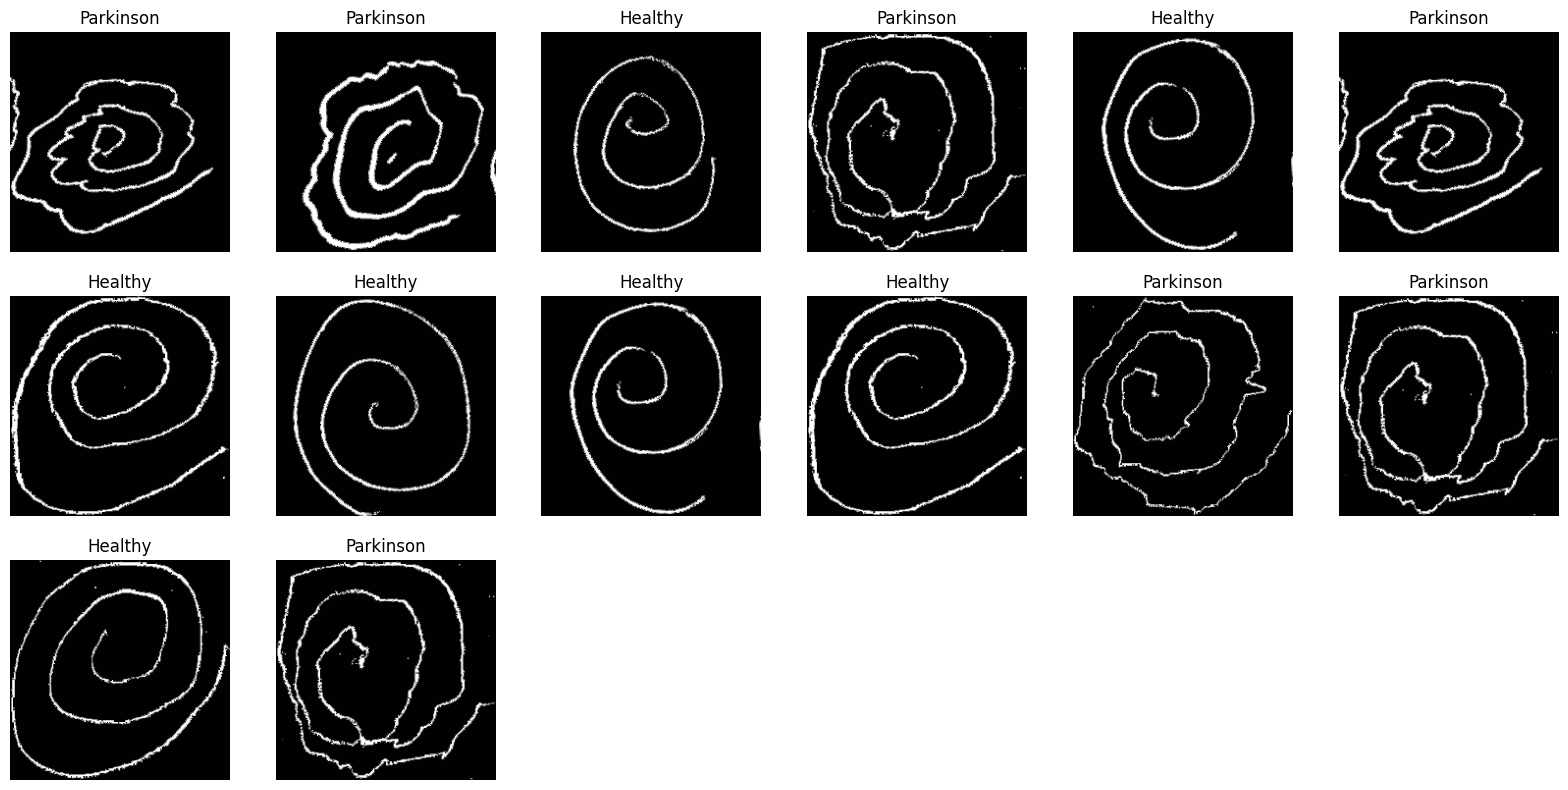

In [ ]:
evaluate_on_test_data(spiral_results["ResNet101"]["Compiled_Model"], spiralTestingPath, le, class_names)

**Training and testing on wave data**

In [ ]:
wave_results,le = train_models(waveTrainingPath, waveValidationPath)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5694 - loss: 42.7765 - val_accuracy: 0.5000 - val_loss: 62.4220 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.4444 - loss: 50.9058 - val_accuracy: 0.9375 - val_loss: 0.4709 - learning_rate: 9.7577e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.6389 - loss: 10.7927 - val_accuracy: 0.9375 - val_loss: 1.3949 - learning_rate: 9.0546e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.7917 - loss: 6.1192 - val_accuracy: 1.0000 - val_loss: 0.0335 - learning_rate: 7.9595e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.7917 - loss: 4.5733 - val_accuracy: 0.8750 - val_loss: 0.2430 - learning_rate: 6.5796e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.8472 - loss: 2.7928 - val_accuracy: 1.0000 - val_loss: 0.0924 - learning_rate: 5.0500e-04
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.8889 - loss: 0

In [ ]:
print("VGG19 vs ResNet101 in wave data\n\n")
for metric in ("Accuracy", "Precision","Recall","Mcc"):
    print(f"{metric.capitalize()}: ")
    print("VGG19={:.2f}%, ResNet101={:.2f}% \n".format(
        wave_results["VGG19"][metric]*100, wave_results["ResNet101"][metric]*100))

VGG19 vs ResNet101 in wave data


Accuracy: 
VGG19=98.61%, ResNet101=83.33% 

Precision: 
VGG19=100.00%, ResNet101=100.00% 

Recall: 
VGG19=97.22%, ResNet101=66.67% 

Mcc: 
VGG19=97.26%, ResNet101=70.71% 



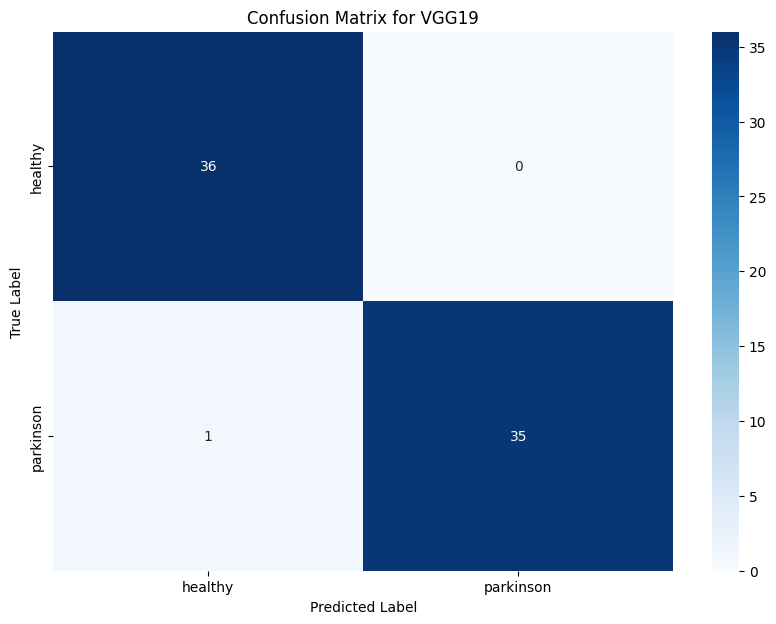

In [ ]:
model_data1 = wave_results.get("VGG19")
if model_data1:
        cm = model_data1["Confusion Matrix"]
        class_names = le.classes_  # Assumes you have le available from training
        plot_confusion_matrix(cm, class_names, "VGG19")

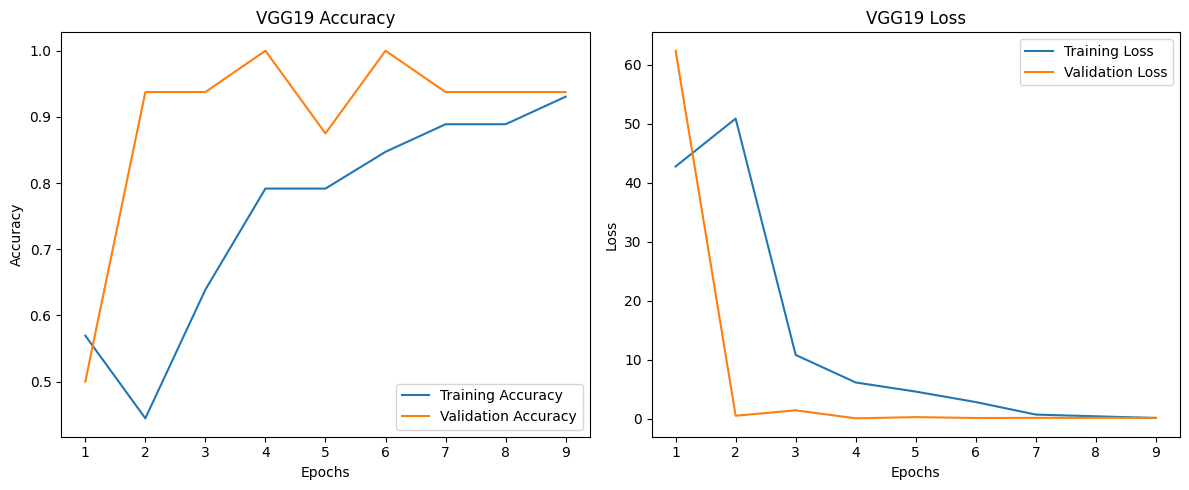

In [ ]:
plot_training_history(wave_results["VGG19"]["History"], model_name="VGG19")

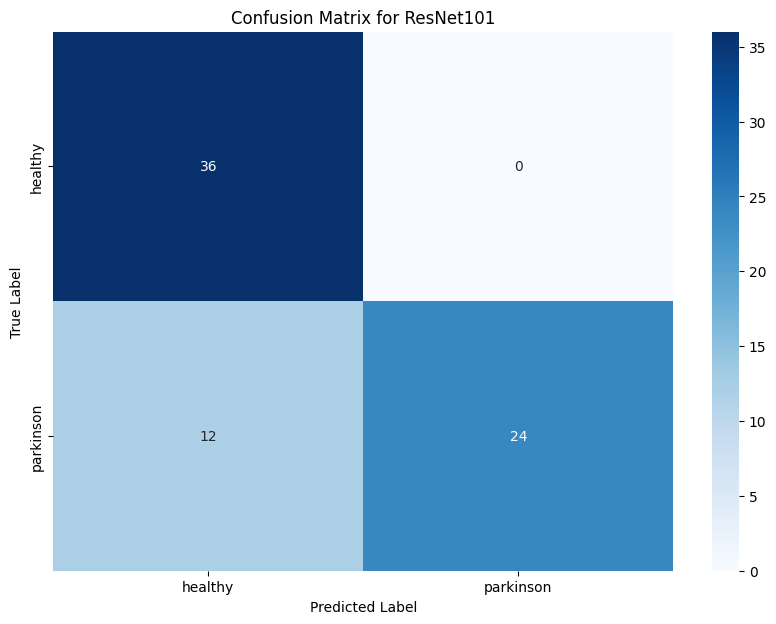

In [ ]:
model_data2 = wave_results.get("ResNet101")
if model_data2:
        cm = model_data2["Confusion Matrix"]
        class_names = le.classes_  # Assumes you have le available from training
        plot_confusion_matrix(cm, class_names, "ResNet101")

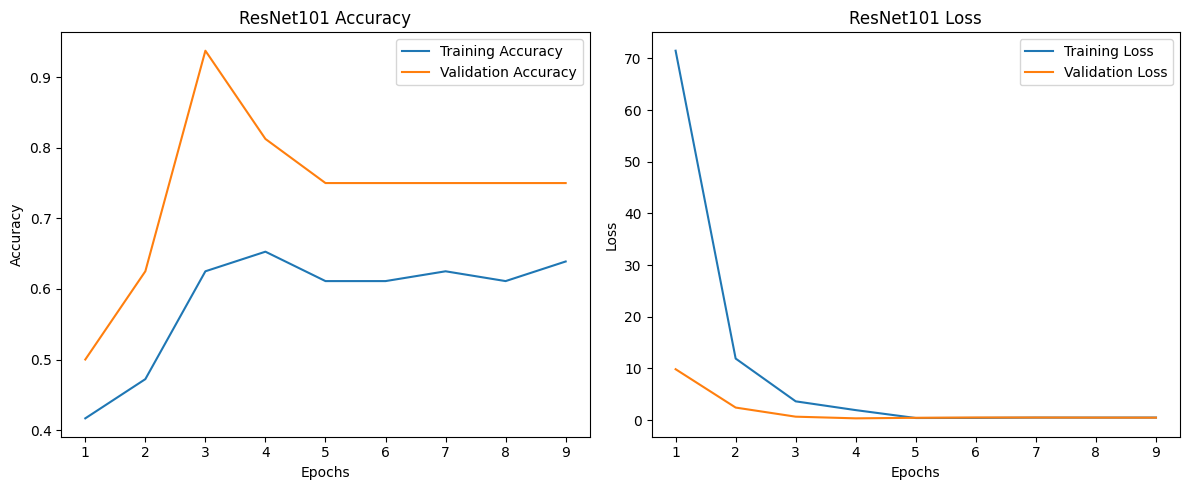

In [ ]:
plot_training_history(wave_results["ResNet101"]["History"], model_name="ResNet101")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.8571 - loss: 1.3091
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
Test Loss: 1.3091, Test Accuracy: 0.8571

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.86      0.86      0.86         7
  Parkinsons       0.86      0.86      0.86         7

    accuracy                           0.86        14
   macro avg       0.86      0.86      0.86        14
weighted avg       0.86      0.86      0.86        14



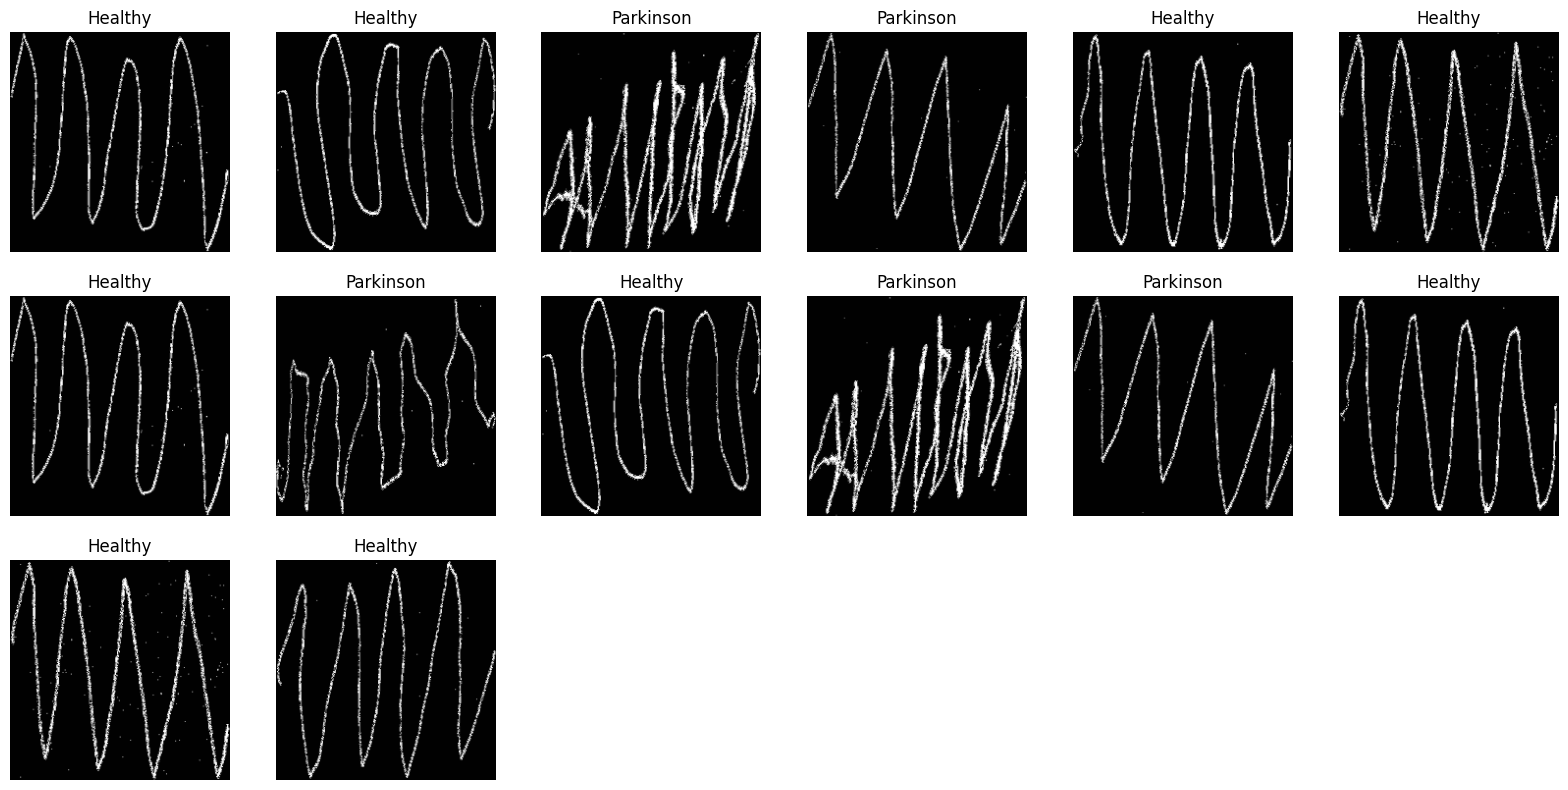

In [ ]:
class_names = ["Healthy", "Parkinsons"]
evaluate_on_test_data(wave_results["VGG19"]["Compiled_Model"], waveTestingPath, le, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6429 - loss: 1.0264
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Test Loss: 1.0264, Test Accuracy: 0.6429

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.64      1.00      0.78         7
  Parkinsons       1.00      0.43      0.60         7

    accuracy                           0.71        14
   macro avg       0.82      0.71      0.69        14
weighted avg       0.82      0.71      0.69        14



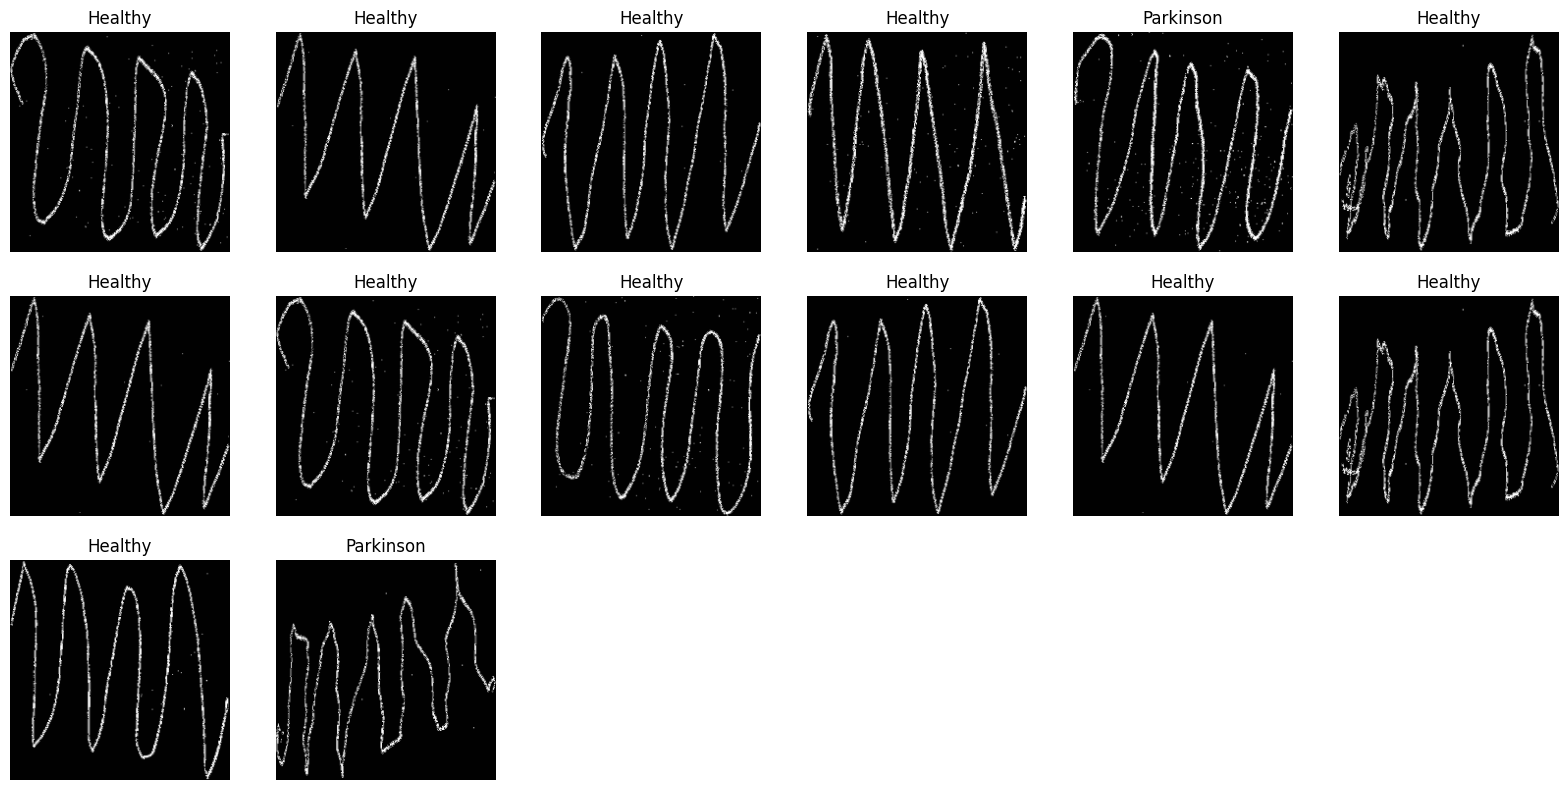

In [ ]:
evaluate_on_test_data(wave_results["ResNet101"]["Compiled_Model"], waveTestingPath, le, class_names)

In [ ]:
# ---------------------------
# SAVE ALL MODELS
# ---------------------------

def save_all_models(results_dict, prefix):
    """
    Saves all trained models in the results dictionary.

    Args:
        results_dict: Dictionary containing model data
        prefix: Prefix name (e.g., 'spiral' or 'wave')
    """
    for model_name, model_data in results_dict.items():
        model = model_data.get("Compiled_Model")

        if model is not None:
            file_name = f"{prefix}_{model_name}.h5"
            model.save(file_name)
            print(f"Saved: {file_name}")
        else:
            print(f"Model not found for: {model_name}")


# Save ALL spiral models
print("\nSaving Spiral Models:")
save_all_models(spiral_results, "spiral")


# Save ALL wave models
print("\nSaving Wave Models:")
save_all_models(wave_results, "wave")


Saving Spiral Models:


Saved: spiral_VGG19.h5


Saved: spiral_ResNet101.h5

Saving Wave Models:
Saved: wave_VGG19.h5
Saved: wave_ResNet101.h5


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os

# 👉 CHANGE THIS if your folder is inside another folder in Drive
base_path = "/content/drive/MyDrive/Spiral_drawing_models"

# Check if path exists
print("Path exists:", os.path.exists(base_path))
print("Contents:", os.listdir(base_path))

Path exists: True
Contents: ['Final_wave_VGG19.h5', 'Final_spiral_ResNet101.h5']


In [45]:
# from tensorflow.keras.models import load_model

# spiral_model = load_model("/content/spiral_ResNet101.h5")
# wave_model = load_model("/content/wave_VGG19.h5")

In [11]:
from tensorflow.keras.models import load_model
# 3. Create full paths for each model
spiral_path = os.path.join(base_path, "Final_spiral_ResNet101.h5")
wave_path = os.path.join(base_path, "Final_wave_VGG19.h5")

# 4. Load the models
spiral_model = load_model(spiral_path)
wave_model = load_model(wave_path)

print("Models loaded successfully from Google Drive!")

Models loaded successfully from Google Drive!


In [12]:
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np

def preprocess_image(img_path):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5],
                             std=[0.5, 0.5, 0.5])
    ])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, image = cv2.threshold(image, 0, 255,
                             cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

    image_pil = Image.fromarray(image)
    image_tensor = transform(image_pil)

    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (image_np * 255).astype(np.uint8)

    image_np = np.expand_dims(image_np, axis=0)

    return image_np

In [13]:
trainX, trainY = load_split(spiralTrainingPath)

all_logits = spiral_model.predict(trainX)

# min_logit = np.min(all_logits)
# max_logit = np.max(all_logits)
min_logit = np.percentile(all_logits, 1)
max_logit = np.percentile(all_logits, 99)
print(min_logit)
print(max_logit)

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step
-16.384981
26.600843


In [14]:
severity_boundary = (0 - min_logit) / (max_logit - min_logit) * 100
print(severity_boundary)

38.117172


In [15]:
def interpret_severity(score):
    if score < 38.117172:
        return "Normal Pattern", "No motor impairment detected."
    elif score < 55:
        return "Mild", "Slight motor irregularities observed."
    elif score < 70:
        return "Moderate", "Noticeable motor impairment detected."
    elif score < 85:
        return "High", "Significant motor impairment observed."
    else:
        return "Severe", "Strong Parkinsonian motor patterns detected."

In [37]:
# import numpy as np

# def predict_spiral(img_path):
#     img = preprocess_image(img_path)

#     # 🔥 Get logit
#     logit = spiral_model.predict(img)[0][0]

#     # Convert to probability (for label only)
#     prob = 1 / (1 + np.exp(-logit))

#     # 🔥 NEW: Logit-based normalization (NO sigmoid)
#     # min_logit = -17.329752
#     # max_logit = 44.843575

#     normalized = (logit - min_logit) / (max_logit - min_logit)
#     normalized = np.clip(normalized, 0, 1)

#     severity_score = normalized * 100

#     label = "Parkinson" if prob > 0.5 else "Healthy"

#     print("\n--- SPIRAL RESULT ---")
#     print(f"Prediction: {label}")
#     print(f"Logit: {logit:.4f}")
#     print(f"PD Probability: {prob:.4f}")
#     print(f"Motor Impairment Score: {severity_score:.2f}/100")

#     return label, severity_score

In [23]:
def predict_spiral(img_path):

    min_logit = -16.384981
    max_logit = 26.600843
    img = preprocess_image(img_path)

    logit = spiral_model.predict(img)[0][0]

    prob = 1 / (1 + np.exp(-logit))

    # Logit normalization (your working method)
    normalized = (logit - min_logit) / (max_logit - min_logit)
    normalized = np.clip(normalized, 0, 1)

    severity_score = normalized * 100

    # 🔥 NEW: Interpretation
    severity_level, description = interpret_severity(severity_score)

    print("\n--- SPIRAL ANALYSIS ---")
    print(f"Logit: {logit:.4f}")
    print(f"Motor Impairment Score: {severity_score:.2f}/100")
    print(f"Severity Level: {severity_level}")
    print(f"Interpretation: {description}")

    return severity_score, severity_level, description

In [13]:
# import numpy as np

# def predict_wave(img_path):
#     img = preprocess_image(img_path)

#     #  Model now outputs LOGITS (not probability)
#     logit = wave_model.predict(img)[0][0]

#     # Convert logit → probability (for classification only)
#     pd_prob = 1 / (1 + np.exp(-logit))

#     #  Use logit for severity (scaled sigmoid)
#     severity_score = 1 / (1 + np.exp(-logit * 0.5)) * 100

#     label = "Parkinson" if pd_prob > 0.5 else "Healthy"

#     print("\n--- WAVE RESULT ---")
#     print(f"Prediction: {label}")
#     print(f"Logit Value: {logit:.4f}")
#     print(f"PD Probability: {pd_prob:.4f}")
#     print(f"Motor Impairment Score: {severity_score:.2f}/100")

#     return label, severity_score

In [17]:
wave_trainX, wave_trainY = load_split(waveTrainingPath)

wave_logits = wave_model.predict(wave_trainX)

wave_min_logit = np.percentile(wave_logits, 5)
wave_max_logit = np.percentile(wave_logits, 95)

print("Wave Min Logit:", wave_min_logit)
print("Wave Max Logit:", wave_max_logit)

3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Wave Min Logit: -45.584194
Wave Max Logit: 78.02814


In [18]:
wave_severity_boundary = (0 - wave_min_logit) / (wave_max_logit - wave_min_logit) * 100
print(wave_severity_boundary)

36.876736


In [64]:
# import numpy as np


# def predict_wave(img_path):
#     img = preprocess_image(img_path)

#     # 🔥 Get logit
#     logit = wave_model.predict(img)[0][0]

#     # Convert to probability (for classification only)
#     prob = 1 / (1 + np.exp(-logit))

#     # 🔥 SAME LOGIC AS SPIRAL (min-max normalization)
#     normalized = (logit - wave_min_logit) / (wave_max_logit - wave_min_logit)
#     normalized = np.clip(normalized, 0, 1)

#     severity_score = normalized * 100

#     label = "Parkinson" if prob > 0.5 else "Healthy"

#     print("\n--- WAVE RESULT ---")
#     print(f"Prediction: {label}")
#     print(f"Logit: {logit:.4f}")
#     print(f"PD Probability: {prob:.4f}")
#     print(f"Motor Impairment Score: {severity_score:.2f}/100")

#     return label, severity_score

In [19]:
def interpret_wave_severity(score):
    if score < 36.876736:
        return "Normal Pattern", "No motor impairment detected."
    elif score < 55:
        return "Mild", "Slight motor irregularities observed."
    elif score < 70:
        return "Moderate", "Noticeable motor impairment detected."
    elif score < 85:
        return "High", "Significant motor impairment observed."
    else:
        return "Severe", "Strong Parkinsonian motor patterns detected."

In [24]:
def predict_wave(img_path):
    wave_min_logit = -45.584194
    wave_max_logit = 78.02814
    img = preprocess_image(img_path)

    logit = wave_model.predict(img)[0][0]

    prob = 1 / (1 + np.exp(-logit))

    # Logit normalization (wave-specific)
    normalized = (logit - wave_min_logit) / (wave_max_logit - wave_min_logit)
    normalized = np.clip(normalized, 0, 1)

    severity_score = normalized * 100

    # 🔥 NEW: Interpretation
    severity_level, description = interpret_wave_severity(severity_score)

    print("\n--- WAVE ANALYSIS ---")
    print(f"Logit: {logit:.4f}")
    print(f"Motor Impairment Score: {severity_score:.2f}/100")
    print(f"Severity Level: {severity_level}")
    print(f"Interpretation: {description}")

    return severity_score, severity_level, description

In [22]:
# Example usage

predict_spiral("/content/V01PE01.png")
predict_spiral("/content/V02PE01.png")
predict_spiral("/content/V03PE01.png")
predict_spiral("/content/V03PE04.png")
predict_spiral("/content/V03PE07.png")
predict_spiral("/content/V05PE01.png")
predict_spiral("/content/V04PE01.png")

# predict_spiral("/content/V03HE1.png")
# predict_spiral("/content/V03HE2.png")
# predict_spiral("/content/V03HE3.png")
# predict_spiral("/content/V04HE01.png")
# predict_spiral("/content/V04HE02.png")
# predict_spiral("/content/V04HE03.png")


# predict_wave("/content/V01PO01.png")
# predict_wave("/content/V02PO01.png")
# predict_wave("/content/V03PO01.png")
# predict_wave("/content/V03PO04.png")
# predict_wave("/content/V03PO07.png")
# predict_wave("/content/V04PO01.png")
# predict_wave("/content/V05PO01.png")
# predict_wave("/content/V06PO01.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

--- SPIRAL ANALYSIS ---
Logit: -0.4482
Motor Impairment Score: 37.07/100
Severity Level: Normal Pattern
Interpretation: No motor impairment detected.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

--- SPIRAL ANALYSIS ---
Logit: 4.6618
Motor Impairment Score: 48.96/100
Severity Level: Mild
Interpretation: Slight motor irregularities observed.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

--- SPIRAL ANALYSIS ---
Logit: 17.7213
Motor Impairment Score: 79.34/100
Severity Level: High
Interpretation: Significant motor impairment observed.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

--- SPIRAL ANALYSIS ---
Logit: 25.1854
Motor Impairment Score: 96.71/100
Severity Level: Severe
Interpretation: Strong Parkinsonian motor patterns detected.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

--- SPIRAL ANALYSIS ---
Logit: 22.0863
Motor Impairment Score: 89.50/100
Severity Level: Severe
Interpretation: Strong Parkinsonian motor patterns detected.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

--- SPIR

(np.float32(66.04087), 'Moderate', 'Noticeable motor impairment detected.')

In [32]:
trainX, trainY = load_split(spiralTrainingPath)

all_logits = spiral_model.predict(trainX)

# min_logit = np.min(all_logits)
# max_logit = np.max(all_logits)
min_logit = np.percentile(all_logits, 1)
max_logit = np.percentile(all_logits, 99)
print(min_logit)
print(max_logit)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
-16.384981
26.600843
